In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
blown_fuses = pd.read_csv('dataset/blown_fuses.csv')
deenergizednodes = pd.read_csv('dataset/de-energized_nodes.csv')
metrics = pd.read_csv('dataset/metrics.csv')
peak_line_overloads = pd.read_csv('dataset/peak_line_overloads.csv')
peak_over_voltages = pd.read_csv('dataset/peak_over_voltages.csv')
peak_transformer_overloads = pd.read_csv('dataset/peak_transformer_overloads.csv')
peak_under_voltages = pd.read_csv('dataset/peak_under_voltages.csv')
peak_voltages = pd.read_csv('dataset/peak_voltages.csv')

,Blown Fuse,Unnamed: 1


In [19]:
# LIMPEZA BÁSICA

def remove_unnamed(df):
    return df.loc[:, ~df.columns.str.contains('^Unnamed')]

blown_fuses = remove_unnamed(blown_fuses)
deenergizednodes = remove_unnamed(deenergizednodes)
metrics = remove_unnamed(metrics)
peak_line_overloads = remove_unnamed(peak_line_overloads)
peak_over_voltages = remove_unnamed(peak_over_voltages)
peak_transformer_overloads = remove_unnamed(peak_transformer_overloads)
peak_under_voltages = remove_unnamed(peak_under_voltages)
peak_voltages = remove_unnamed(peak_voltages)


In [20]:
# VISÃO GERAL

datasets = {
    'blown_fuses': blown_fuses,
    'deenergizednodes': deenergizednodes,
    'metrics': metrics,
    'peak_line_overloads': peak_line_overloads,
    'peak_over_voltages': peak_over_voltages,
    'peak_transformer_overloads': peak_transformer_overloads,
    'peak_under_voltages': peak_under_voltages,
    'peak_voltages': peak_voltages
}

for name, df in datasets.items():
    print('=' * 60)
    print(f'DATASET: {name}')
    print('=' * 60)

    print('\nShape:')
    print(df.shape)

    print('\nColumns:')
    print(df.columns.tolist())

    print('\nMissing Values:')
    print(df.isnull().sum())

    print('\n')

DATASET: blown_fuses

Shape:
(0, 1)

Columns:
['Blown Fuse']

Missing Values:
Blown Fuse    0
dtype: int64


DATASET: deenergizednodes

Shape:
(301, 1)

Columns:
['De-Energized Bus due to Open Switch (or Blown Fuse)']

Missing Values:
De-Energized Bus due to Open Switch (or Blown Fuse)    0
dtype: int64


DATASET: metrics

Shape:
(454, 80)

Columns:
['Feeder Name', 'Feeder Head Node', 'Substation Name', 'Medium Voltage Length (miles)', 'Three Phase Medium Voltage Length (miles)', 'Three Phase Overhead Medium Voltage Length (miles)', 'Two Phase Medium Voltage Length (miles)', 'Two Phase Overhead Medium Voltage Length (miles)', 'Single Phase Medium Voltage Length (miles)', 'Single Phase Overhead Medium Voltage Length (miles)', 'Overhead Percentage of Medium Voltage Line Miles', 'Ratio of Medium Voltage Lines to Number of Customers', 'Maximum Node Distance From Substation (miles)', 'Nominal Voltage of Source (kV)', 'Low Voltage Length (miles)', 'Three Phase Low Voltage Length (miles)', 'T

In [21]:
# ANÁLISE DAS MÉTRICAS DOS FEEDERS

print(metrics.describe())

       Medium Voltage Length (miles)  \
count                     454.000000   
mean                       15.795055   
std                        11.026526   
min                         0.036400   
25%                         8.246575   
50%                        13.994450   
75%                        21.000350   
max                        62.211500   

       Three Phase Medium Voltage Length (miles)  \
count                                 454.000000   
mean                                    7.376174   
std                                     5.160673   
min                                     0.036400   
25%                                     4.184875   
50%                                     6.248400   
75%                                     9.742925   
max                                    32.922800   

       Three Phase Overhead Medium Voltage Length (miles)  \
count                                         454.000000    
mean                                            

In [22]:
# TOP FEEDERS POR CARGA

top_load = metrics.sort_values(
    by='Total Peak Planning Load (MW)',
    ascending=False
)[[
    'Feeder Name',
    'Total Peak Planning Load (MW)',
    'Total Number of Customers'
]].head(10)

print(top_load)

                  Feeder Name  Total Peak Planning Load (MW)  \
377  p5uhs17_1247--p5udt28507                        17.3645   
407   p5uhs8_1247--p5udt24709                        17.3016   
163    p3uhs7_1247--p3udt9478                        17.2465   
345    p5uhs4_1247--p5udt2507                        17.2010   
205   p3uhs6_1247--p3udt31448                        17.0113   
14      p1uhs1_1247--p1udt138                        17.0015   
338    p5uhs1_1247--p5udt4629                        16.8642   
335    p5uhs1_1247--p5udt6125                        16.7271   
203   p3uhs4_1247--p3udt14887                        16.6000   
36    p1uhs0_1247--p1udt12703                        16.4981   

     Total Number of Customers  
377                     1249.0  
407                      854.0  
163                     1813.0  
345                     1220.0  
205                     2113.0  
14                       990.0  
338                      262.0  
335                      373.0 

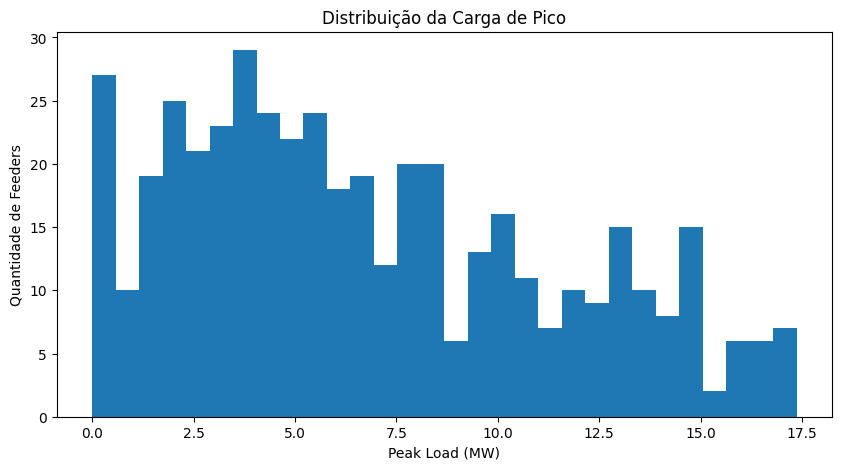

In [23]:
# HISTOGRAMA DE CARGA

plt.figure(figsize=(10, 5))

plt.hist(
    metrics['Total Peak Planning Load (MW)'],
    bins=30
)

plt.xlabel('Peak Load (MW)')
plt.ylabel('Quantidade de Feeders')
plt.title('Distribuição da Carga de Pico')

plt.show()

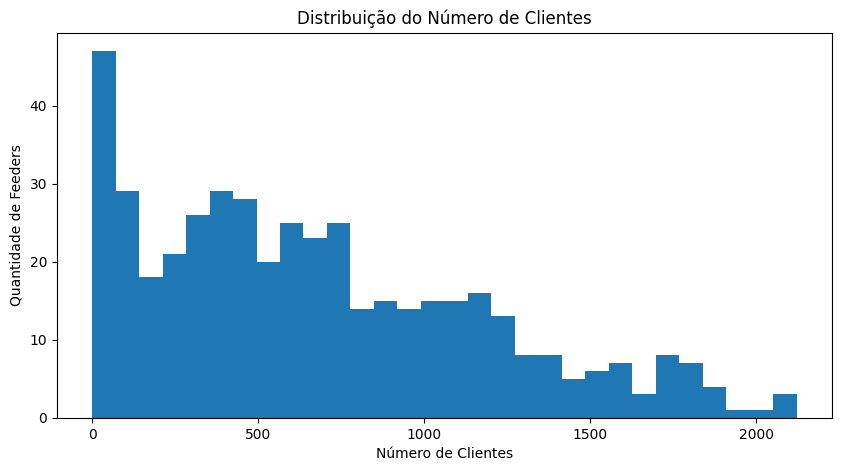

In [24]:
# HISTOGRAMA DE CLIENTES

plt.figure(figsize=(10, 5))

plt.hist(
    metrics['Total Number of Customers'],
    bins=30
)

plt.xlabel('Número de Clientes')
plt.ylabel('Quantidade de Feeders')
plt.title('Distribuição do Número de Clientes')

plt.show()

In [25]:
# ANÁLISE DE SOBRECARGA DE LINHAS

print('\nQuantidade de linhas sobrecarregadas:')
print(len(peak_line_overloads))

print('\nMaior carregamento encontrado:')
print(peak_line_overloads['Loading (p.u.)'].max())



Quantidade de linhas sobrecarregadas:
585

Maior carregamento encontrado:
1.5051252655143856


In [26]:
# ANÁLISE DE SOBRECARGA DE TRANSFORMADORES

print('\nQuantidade de transformadores sobrecarregados:')
print(len(peak_transformer_overloads))

print('\nMaior carregamento encontrado:')
print(peak_transformer_overloads['Loading (p.u.)'].max())


Quantidade de transformadores sobrecarregados:
56

Maior carregamento encontrado:
1.0472204849965705


In [27]:
# ANÁLISE DE TENSÕES

print('\nMaior sobretensão:')
print(peak_over_voltages['OpenDSS Value (p.u.)'].max())

print('\nMenor tensão encontrada:')
print(peak_voltages['OpenDSS Value (p.u.)'].min())


Maior sobretensão:
1.051169011569408

Menor tensão encontrada:
0.9202660700965763


In [28]:
# BARRAMENTOS DESENERGIZADOS

print('\nQuantidade de nós desenergizados:')
print(len(deenergizednodes))


Quantidade de nós desenergizados:
301


In [29]:
# FUSÍVEIS QUEIMADOS

print('\nQuantidade de fusíveis queimados:')
print(len(blown_fuses))


Quantidade de fusíveis queimados:
0


In [30]:
# ANÁLISE DE PERFIL DOS CONSUMIDORES

consumer_profile = metrics[[
    'Percentage of Residential Customers',
    'Percentage of Commercial Customers',
    'Percentage of Industrial Customers'
]].mean()

print('\nPerfil médio dos consumidores:')
print(consumer_profile)


Perfil médio dos consumidores:
Percentage of Residential Customers    88.687055
Percentage of Commercial Customers      5.822930
Percentage of Industrial Customers      5.490015
dtype: float64


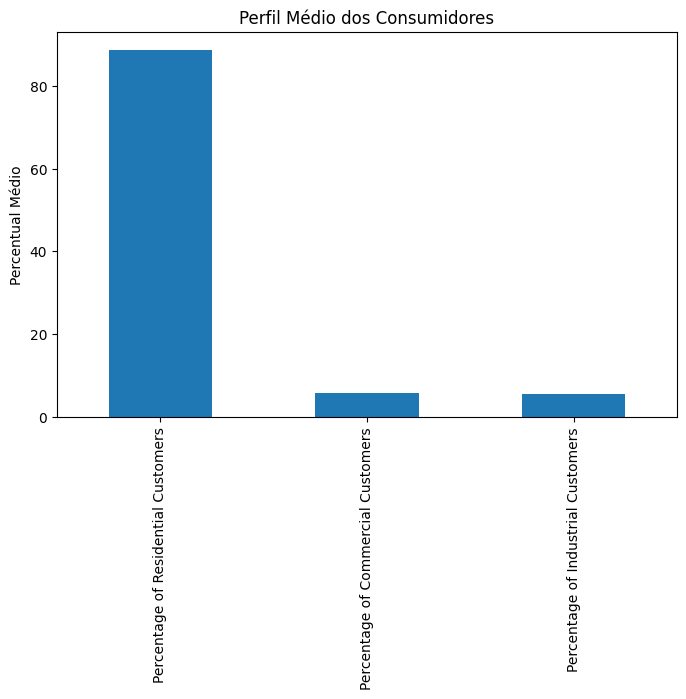

In [31]:
# GRÁFICO DE PERFIL DOS CONSUMIDORES

plt.figure(figsize=(8, 5))

consumer_profile.plot(kind='bar')

plt.ylabel('Percentual Médio')
plt.title('Perfil Médio dos Consumidores')

plt.show()


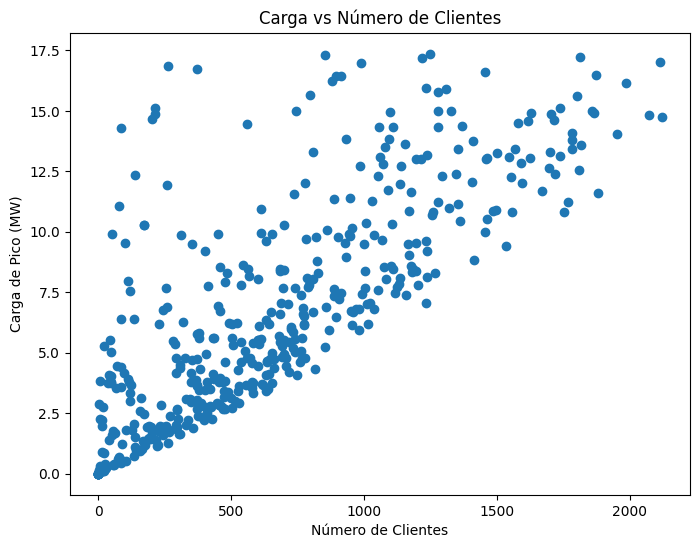

In [32]:
# RELAÇÃO ENTRE CARGA E CLIENTES

plt.figure(figsize=(8, 6))

plt.scatter(
    metrics['Total Number of Customers'],
    metrics['Total Peak Planning Load (MW)']
)

plt.xlabel('Número de Clientes')
plt.ylabel('Carga de Pico (MW)')
plt.title('Carga vs Número de Clientes')

plt.show()

In [33]:
# ESTATÍSTICAS DE TENSÃO

print('\nEstatísticas de tensão mínima:')
print(peak_voltages['OpenDSS Value (p.u.)'].describe())


Estatísticas de tensão mínima:
count    855710.000000
mean          1.001541
std           0.011388
min           0.920266
25%           0.994499
50%           1.002593
75%           1.009599
max           1.049194
Name: OpenDSS Value (p.u.), dtype: float64


In [34]:
# ESTATÍSTICAS DE SOBRETENSÃO

print('\nEstatísticas de sobretensão:')
print(peak_over_voltages['OpenDSS Value (p.u.)'].describe())


Estatísticas de sobretensão:
count    1.000000
mean     1.051169
std           NaN
min      1.051169
25%      1.051169
50%      1.051169
75%      1.051169
max      1.051169
Name: OpenDSS Value (p.u.), dtype: float64


In [35]:
# ESTATÍSTICAS DE SOBRECARGA

print('\nEstatísticas de sobrecarga de linhas:')
print(peak_line_overloads['Loading (p.u.)'].describe())

print('\nEstatísticas de sobrecarga de transformadores:')
print(peak_transformer_overloads['Loading (p.u.)'].describe())


Estatísticas de sobrecarga de linhas:
count    585.000000
mean       1.034882
std        0.048325
min        1.000666
25%        1.014043
50%        1.026889
75%        1.040988
max        1.505125
Name: Loading (p.u.), dtype: float64

Estatísticas de sobrecarga de transformadores:
count    56.000000
mean      1.023368
std       0.012297
min       1.001200
25%       1.014876
50%       1.022588
75%       1.032967
max       1.047220
Name: Loading (p.u.), dtype: float64
